# [LAB-06] 15. 다중 Sub Plot

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from matplotlib import pyplot as plt
from helper import my_plot
from pandas import pivot_table
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('traffic_acc')
origin.head()

📚 2005년 1월 부터 2018년 12월 까지 월별 교통사고의 발생건수,부상자수,사망자수 데이터(인덱스/메타데이터 없음, 출처: 공공데이터포털)


,년도,월,발생건수,사망자수,부상자수
0,2005,1,15494,504,25413
1,2005,2,13244,431,21635
2,2005,3,16580,477,25550
3,2005,4,17817,507,28131
4,2005,5,19085,571,29808


### 3. 데이터 전처리

각 변수를 년도별 평균값으로 전처리 한다.

In [3]:
df = origin.drop('월', axis=1).groupby('년도').mean()
df

,발생건수,사망자수,부상자수
년도,,,
2005,17847.583,531.333,28519.417
2006,17812.083,527.250,28352.417
2007,17638.500,513.833,27992.167
2008,17985.167,489.167,28246.833
2009,19332.500,486.500,30156.250
2010,18906.500,458.750,29371.500
2011,18475.917,435.750,28449.250
2012,18638.000,449.333,28713.750
2013,17946.167,424.333,27392.583


### 4. 히트맵 시각화를 위한 데이터 재배치

In [4]:
hmdf = pivot_table(origin, index='년도', columns='월', values='발생건수')
hmdf

월,1,2,3,4,5,6,7,8,9,10,11,12
년도,,,,,,,,,,,,
2005,15494.000,13244.000,16580.000,17817.000,19085.000,18092.000,18675.000,19035.000,18759.000,19757.000,19129.000,18504.000
2006,14971.000,14270.000,16767.000,17948.000,19140.000,17435.000,18634.000,18794.000,19293.000,19100.000,19877.000,17516.000
2007,14914.000,14696.000,18166.000,18055.000,19264.000,18310.000,18037.000,17982.000,18506.000,19026.000,17815.000,16891.000
2008,14741.000,14176.000,16752.000,17498.000,19515.000,18824.000,19562.000,18545.000,18023.000,19926.000,19597.000,18663.000
2009,16532.000,15502.000,18224.000,19153.000,20237.000,19249.000,20281.000,19993.000,21004.000,21440.000,20156.000,20219.000
2010,17124.000,15803.000,17801.000,18386.000,20372.000,18910.000,18965.000,19383.000,19439.000,21575.000,20271.000,18849.000
2011,16454.000,14208.000,16832.000,18570.000,19414.000,18505.000,19253.000,18896.000,19065.000,20952.000,20283.000,19279.000
2012,16818.000,16656.000,18255.000,19372.000,19672.000,18854.000,19333.000,18407.000,19234.000,19557.000,19750.000,17748.000
2013,16016.000,14187.000,17465.000,18031.000,19686.000,18329.000,18441.000,18691.000,17806.000,19797.000,19396.000,17509.000


### 5. 파이 그래프를 위한 데이터 집계

In [5]:
piedf = origin[['월', '발생건수']].groupby('월').sum().reset_index()
piedf

,월,발생건수
0,1,226934
1,2,208446
2,3,245893
3,4,257820
4,5,273934
5,6,257793
6,7,266920
7,8,264608
8,9,267328
9,10,281996


## #02. 서브플롯 초기화

### 1. 2행 3열을 갖는 서브플롯 영역 구성하기

```python
fig, ax = pyplot.subplots(행, 열 [, figsize=(가로크기, 세로크기)])
```

- `plt.subplots()` 메서드에 의해 리턴되는 `fig`는 그래픽 처리 기능을 제공하는 객체이다.
- `plt.subplots()` 메서드에 의해 리턴되는 `ax`객체는 분할된 각 그래프 영역의 객체를 저장하고 있는 리스트이다.

총 6개의 ax 객체가 생성되었습니다.


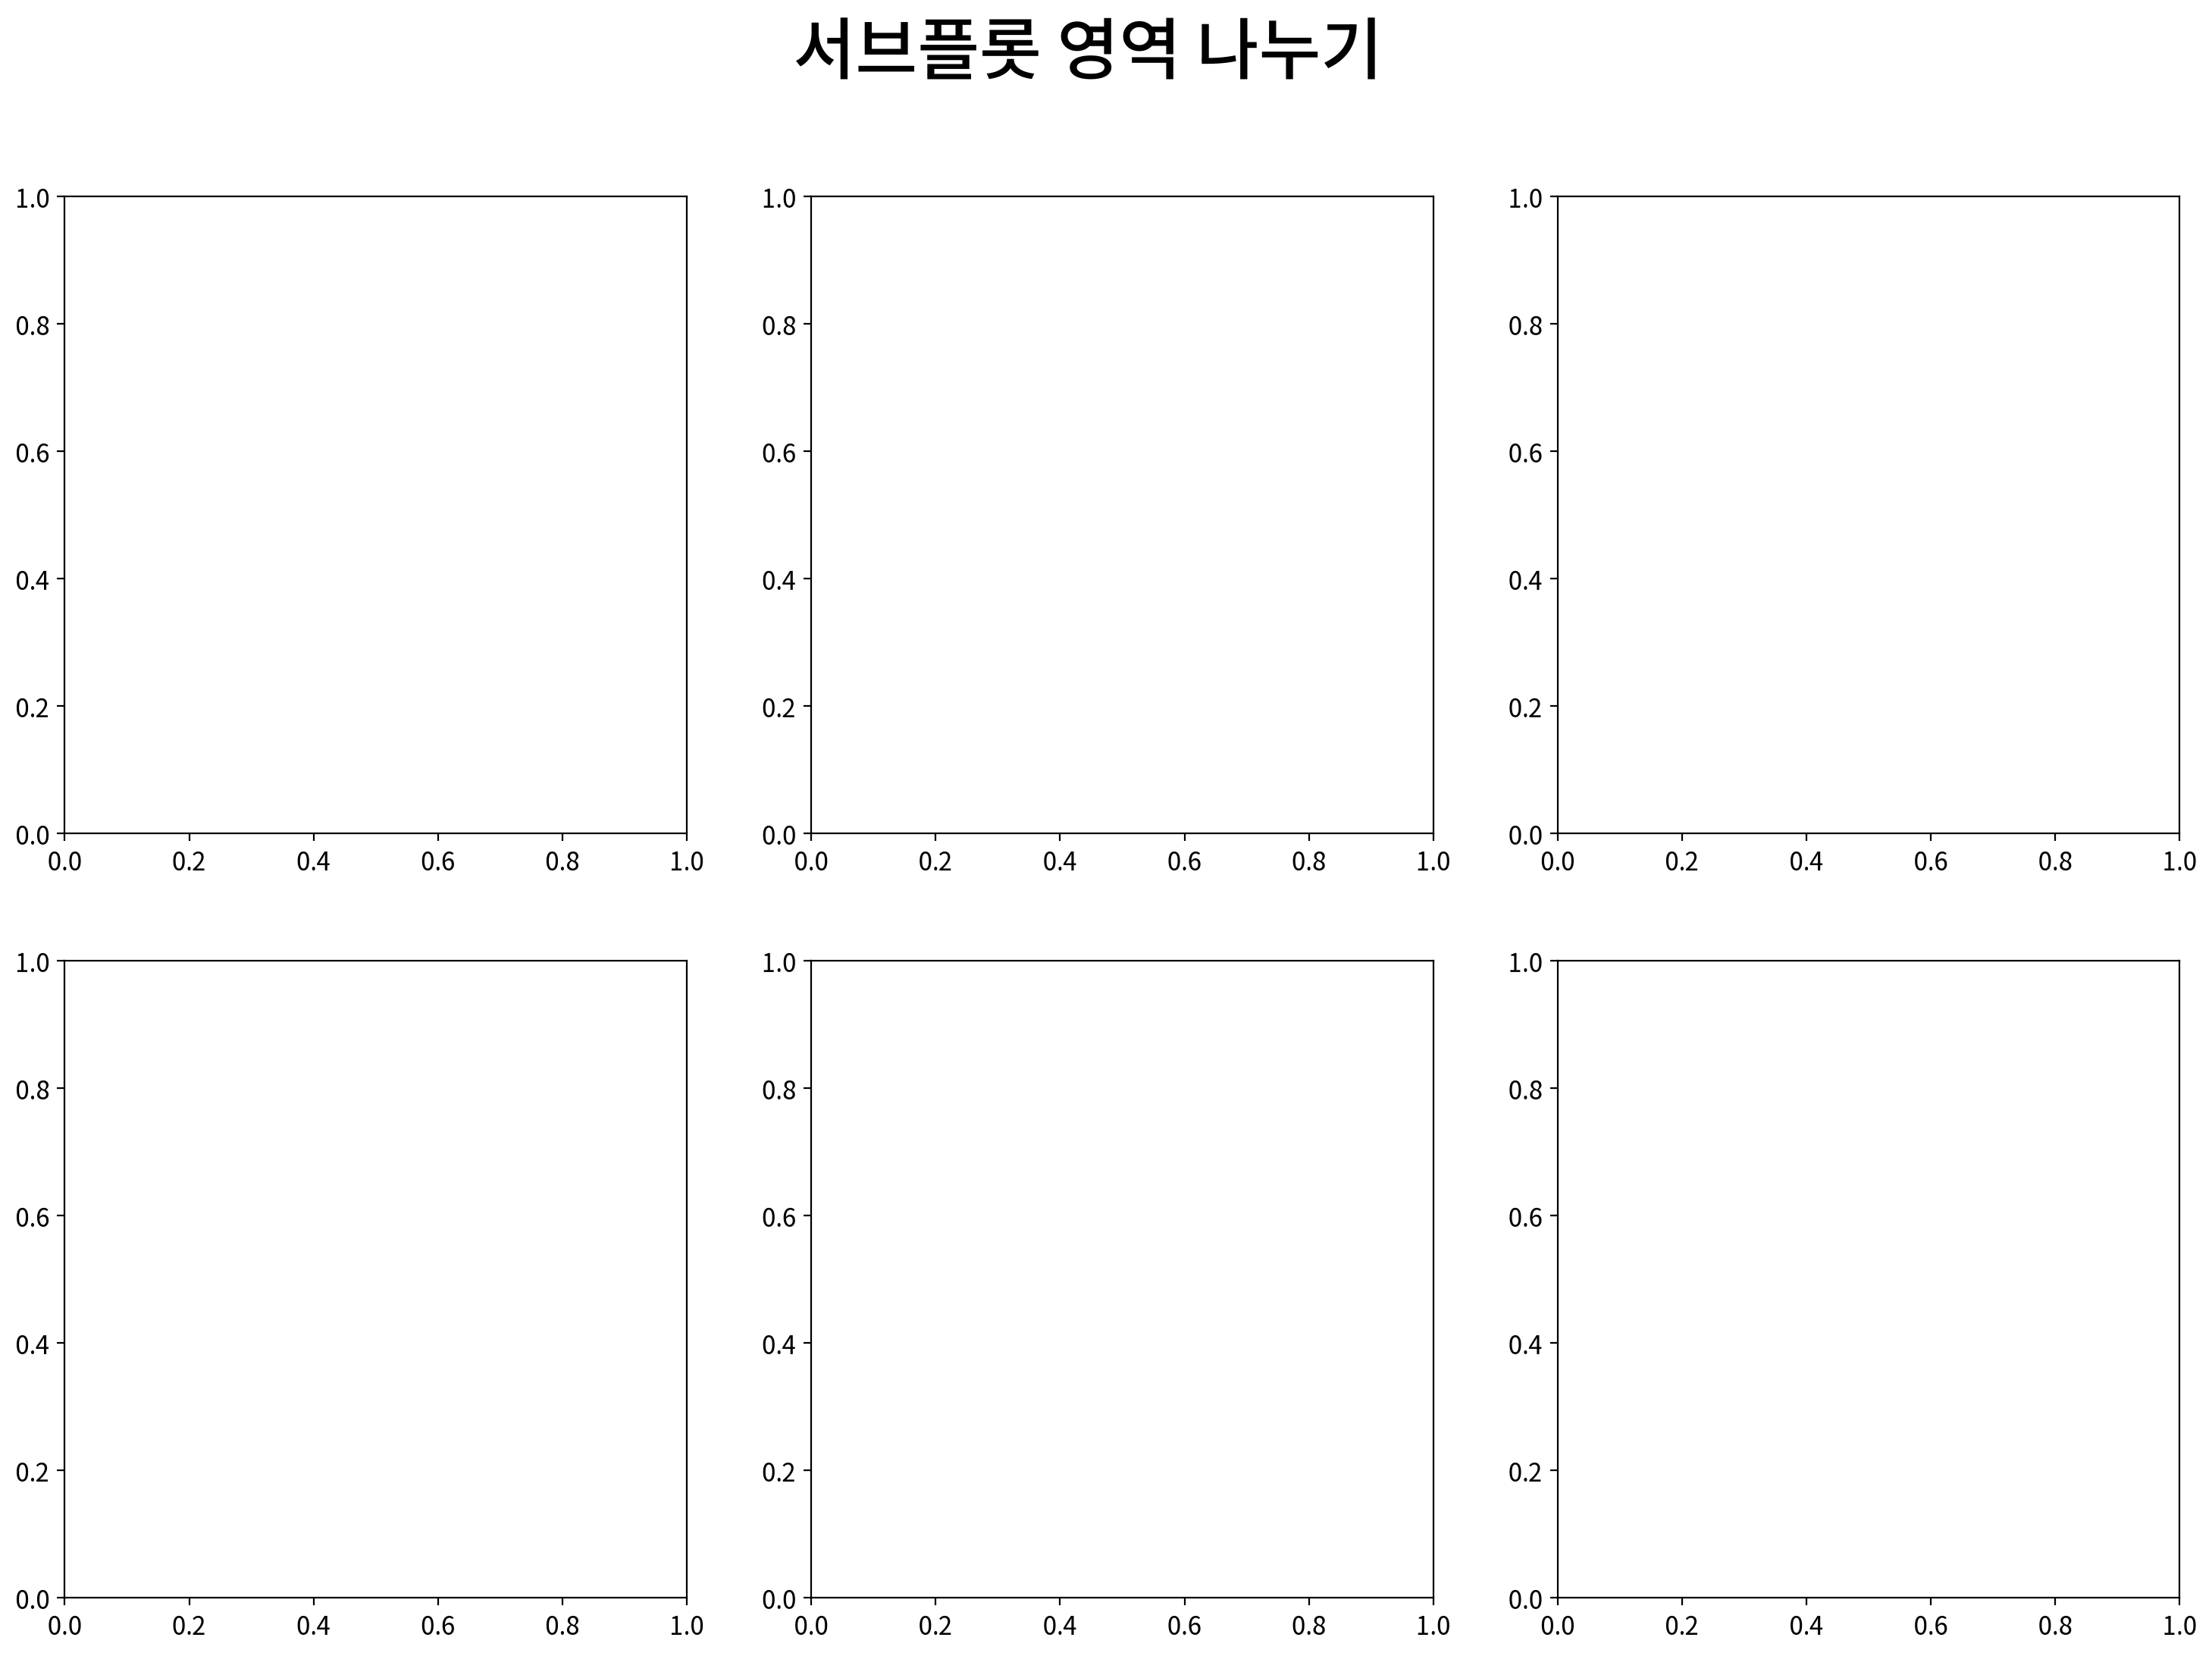

In [6]:
# 1) 그래프 초기화 (가로 600, 세로 400, 행 2개, 열 3개, 해상도 200 후 figsize ='width * cols' / 100, height * rows / 100)
width = 600
height = 600
rows = 2
cols = 3
my_dpi = 200
figsize = (width * cols / 100, height * rows / 100)

# ax 객체가 행,열 수에 따라서 리스트가 된다.
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
    # ax 객체를 1차원 리스트로 변환
ax = ax.flatten()

print(f'총 {len(ax)}개의 ax 객체가 생성되었습니다.')


# 2) 그래프 그리기
# ...

# 3) 그래프 꾸미기
# 전체 제목
fig.suptitle('서브플롯 영역 나누기', fontsize=32, fontweight=500)

# 4) 출력
plt.show()

### 2. 서브플롯 초기화 모듈 기능 확인

총 6개의 ax 객체가 생성되었습니다.


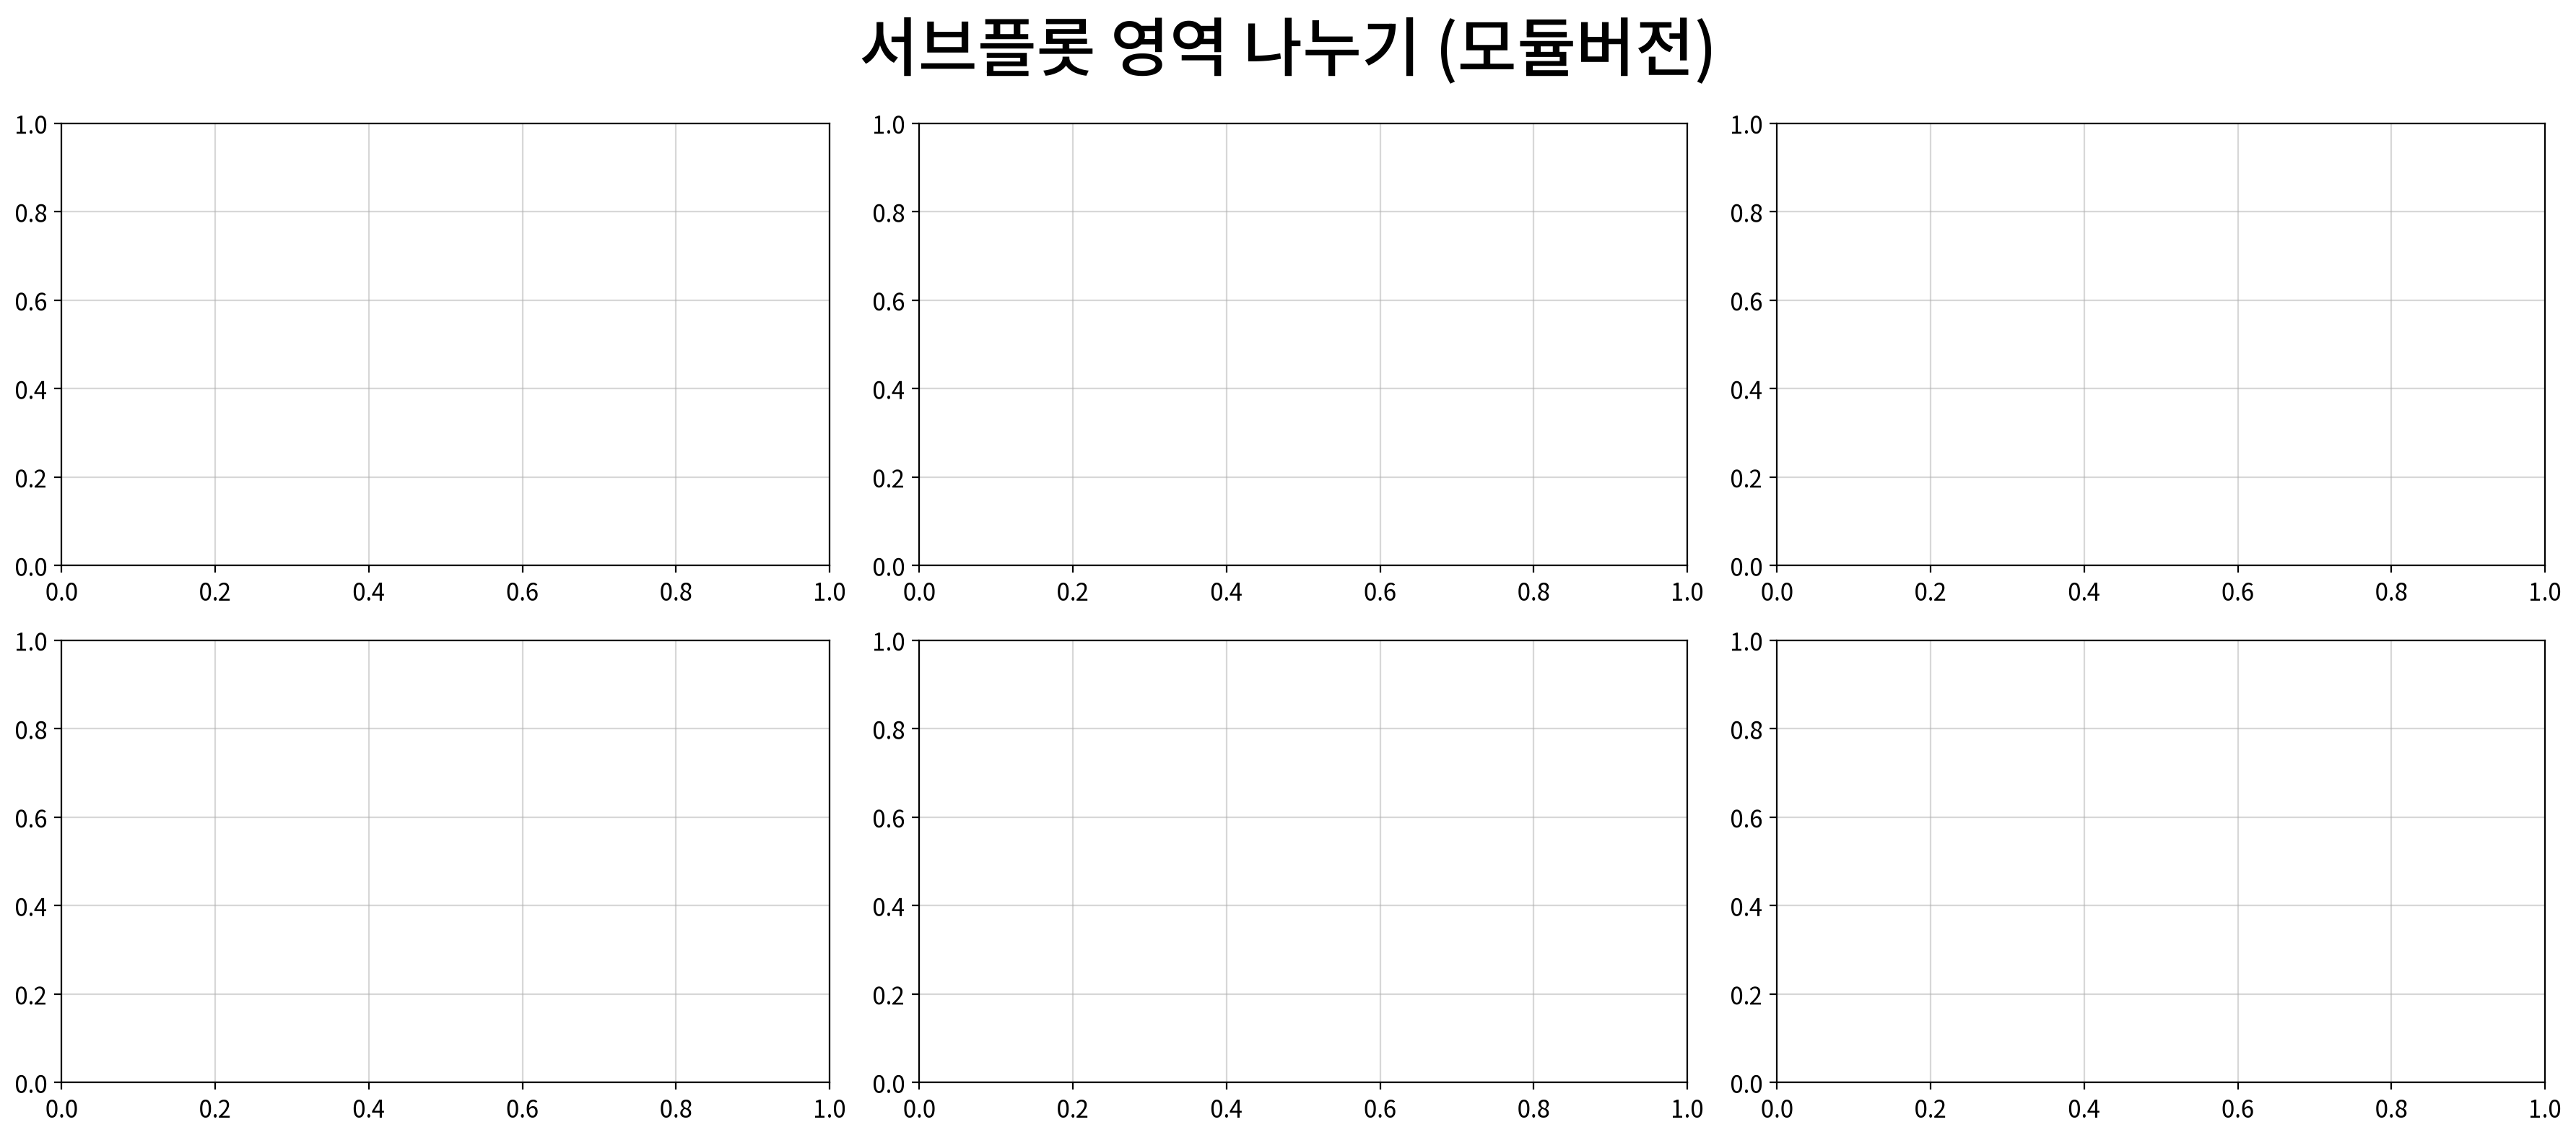

In [7]:
fig, ax = my_plot.init(width=600, height=400, rows=2, cols=3, title='서브플롯 영역 나누기 (모듈버전)')

print(f'총 {len(ax)}개의 ax 객체가 생성되었습니다.')

my_plot.show()

## #03. 서브 플롯에 그래프 표시하기

### 1. seaborn을 사용하여 직접 구현하기

- lmplot과 pairplot을 제외한 모든 그래프 함수에 ax 파라미터를 사용하여 출력될 캔버스를 지정한다.

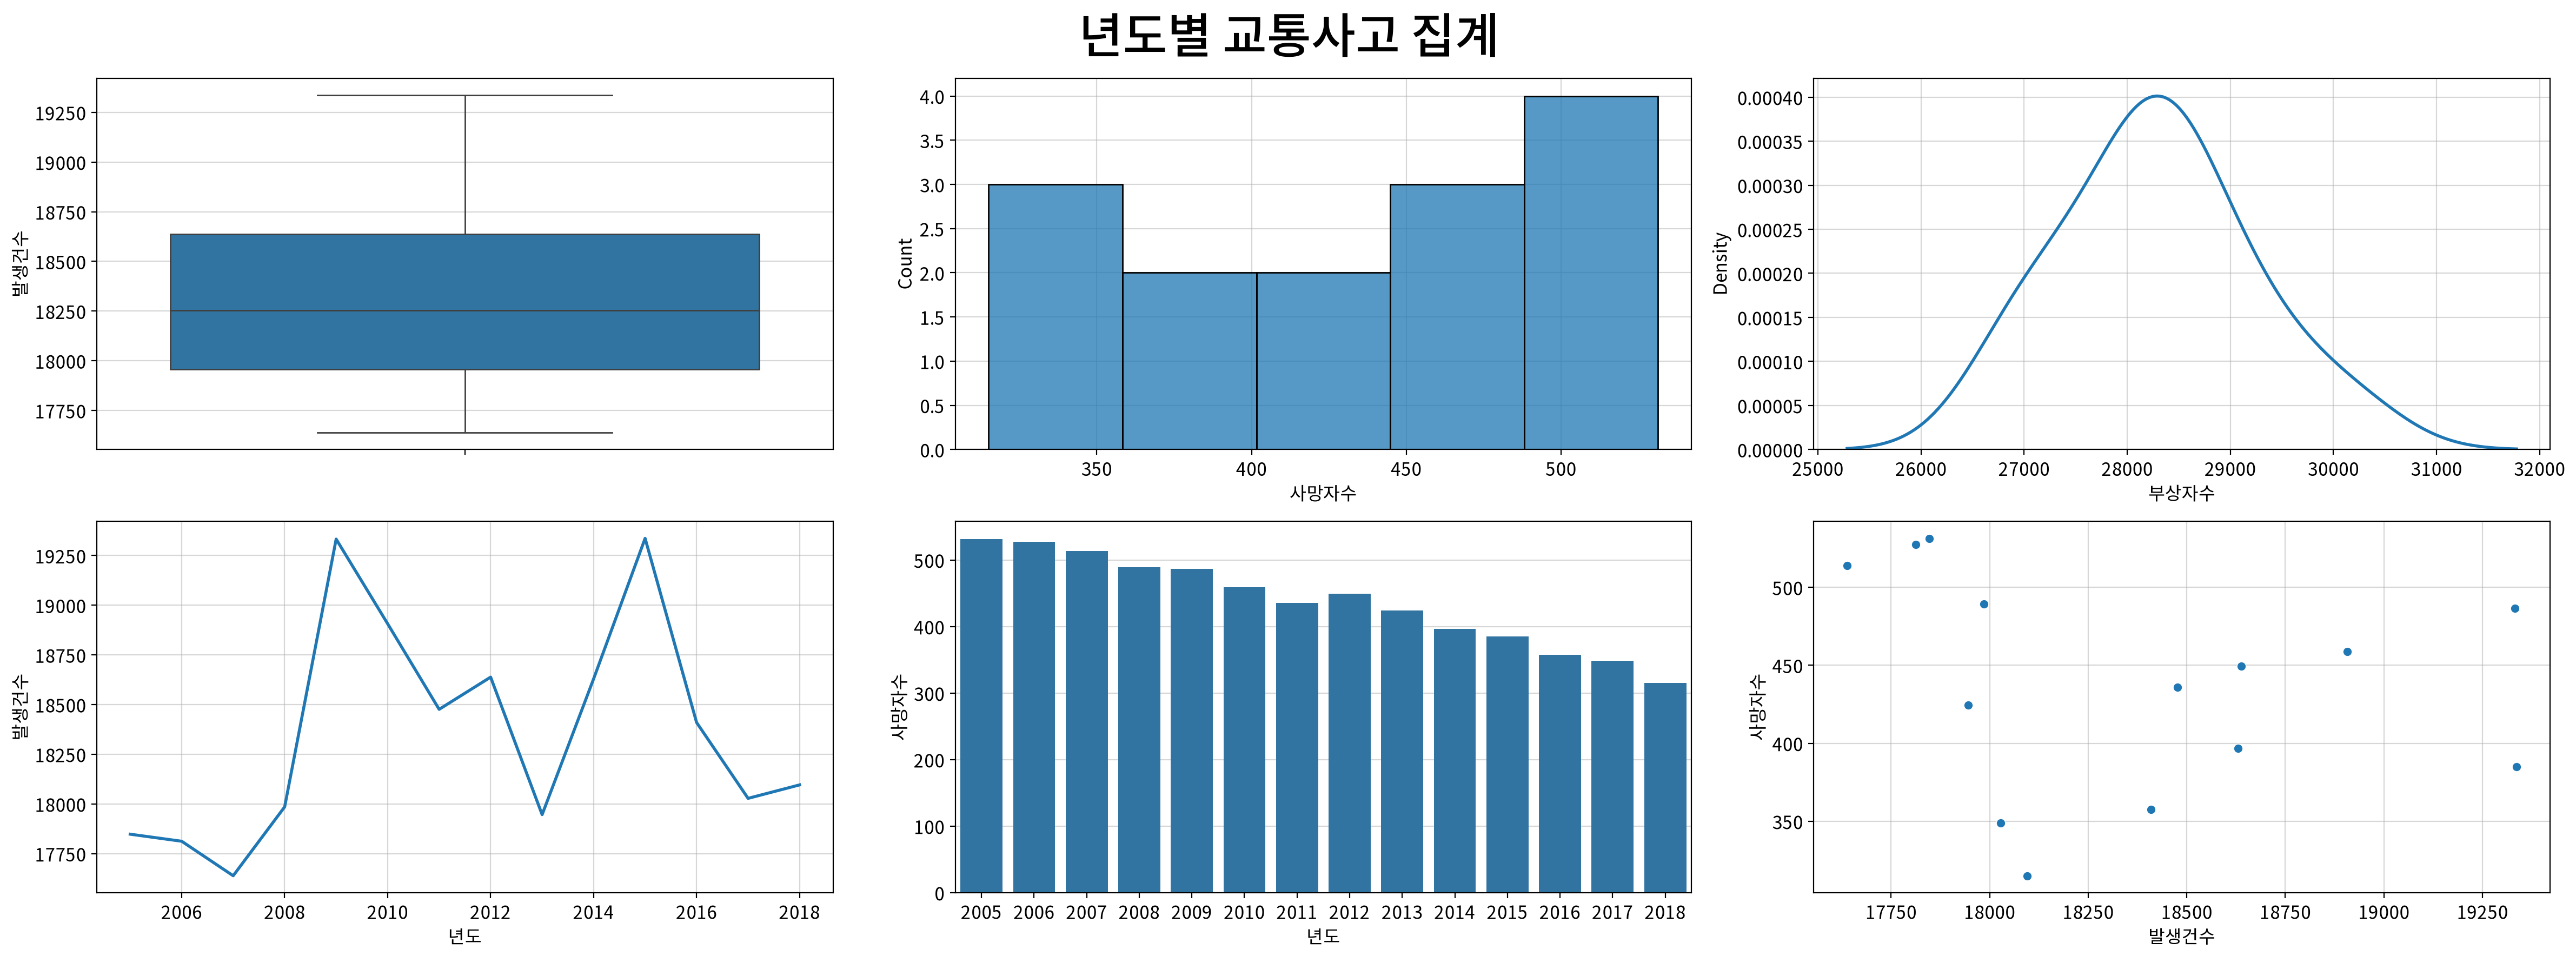

In [8]:
# 1) 그래프 초기화(행 2개, 열 3개 ,가로 800, 높이 450, 제목: 년도별 교통사고 집계)
fig, ax = my_plot.init(rows=2, cols=3, width=800, height=450, title='년도별 교통사고 집계')

# 2) 그래프 그리기 (boxplot, histplot, kdeplot, lineplot, barplot, scatterplot)
sb.boxplot(data=df, y='발생건수', ax=ax[0])
sb.histplot(data=df, x='사망자수', ax=ax[1])
sb.kdeplot(data=df, x='부상자수', ax=ax[2])
sb.lineplot(data=df, x=df.index, y='발생건수', ax=ax[3])
sb.barplot(data=df, x=df.index, y='사망자수', estimator=np.sum, ax=ax[4])
sb.scatterplot(data=df, x='발생건수', y='사망자수', ax=ax[5]
               )
# 3) 출력
my_plot.show()

### 4. 모듈을 활용하여 지금까지 살펴본 모든 그래프 표시하기

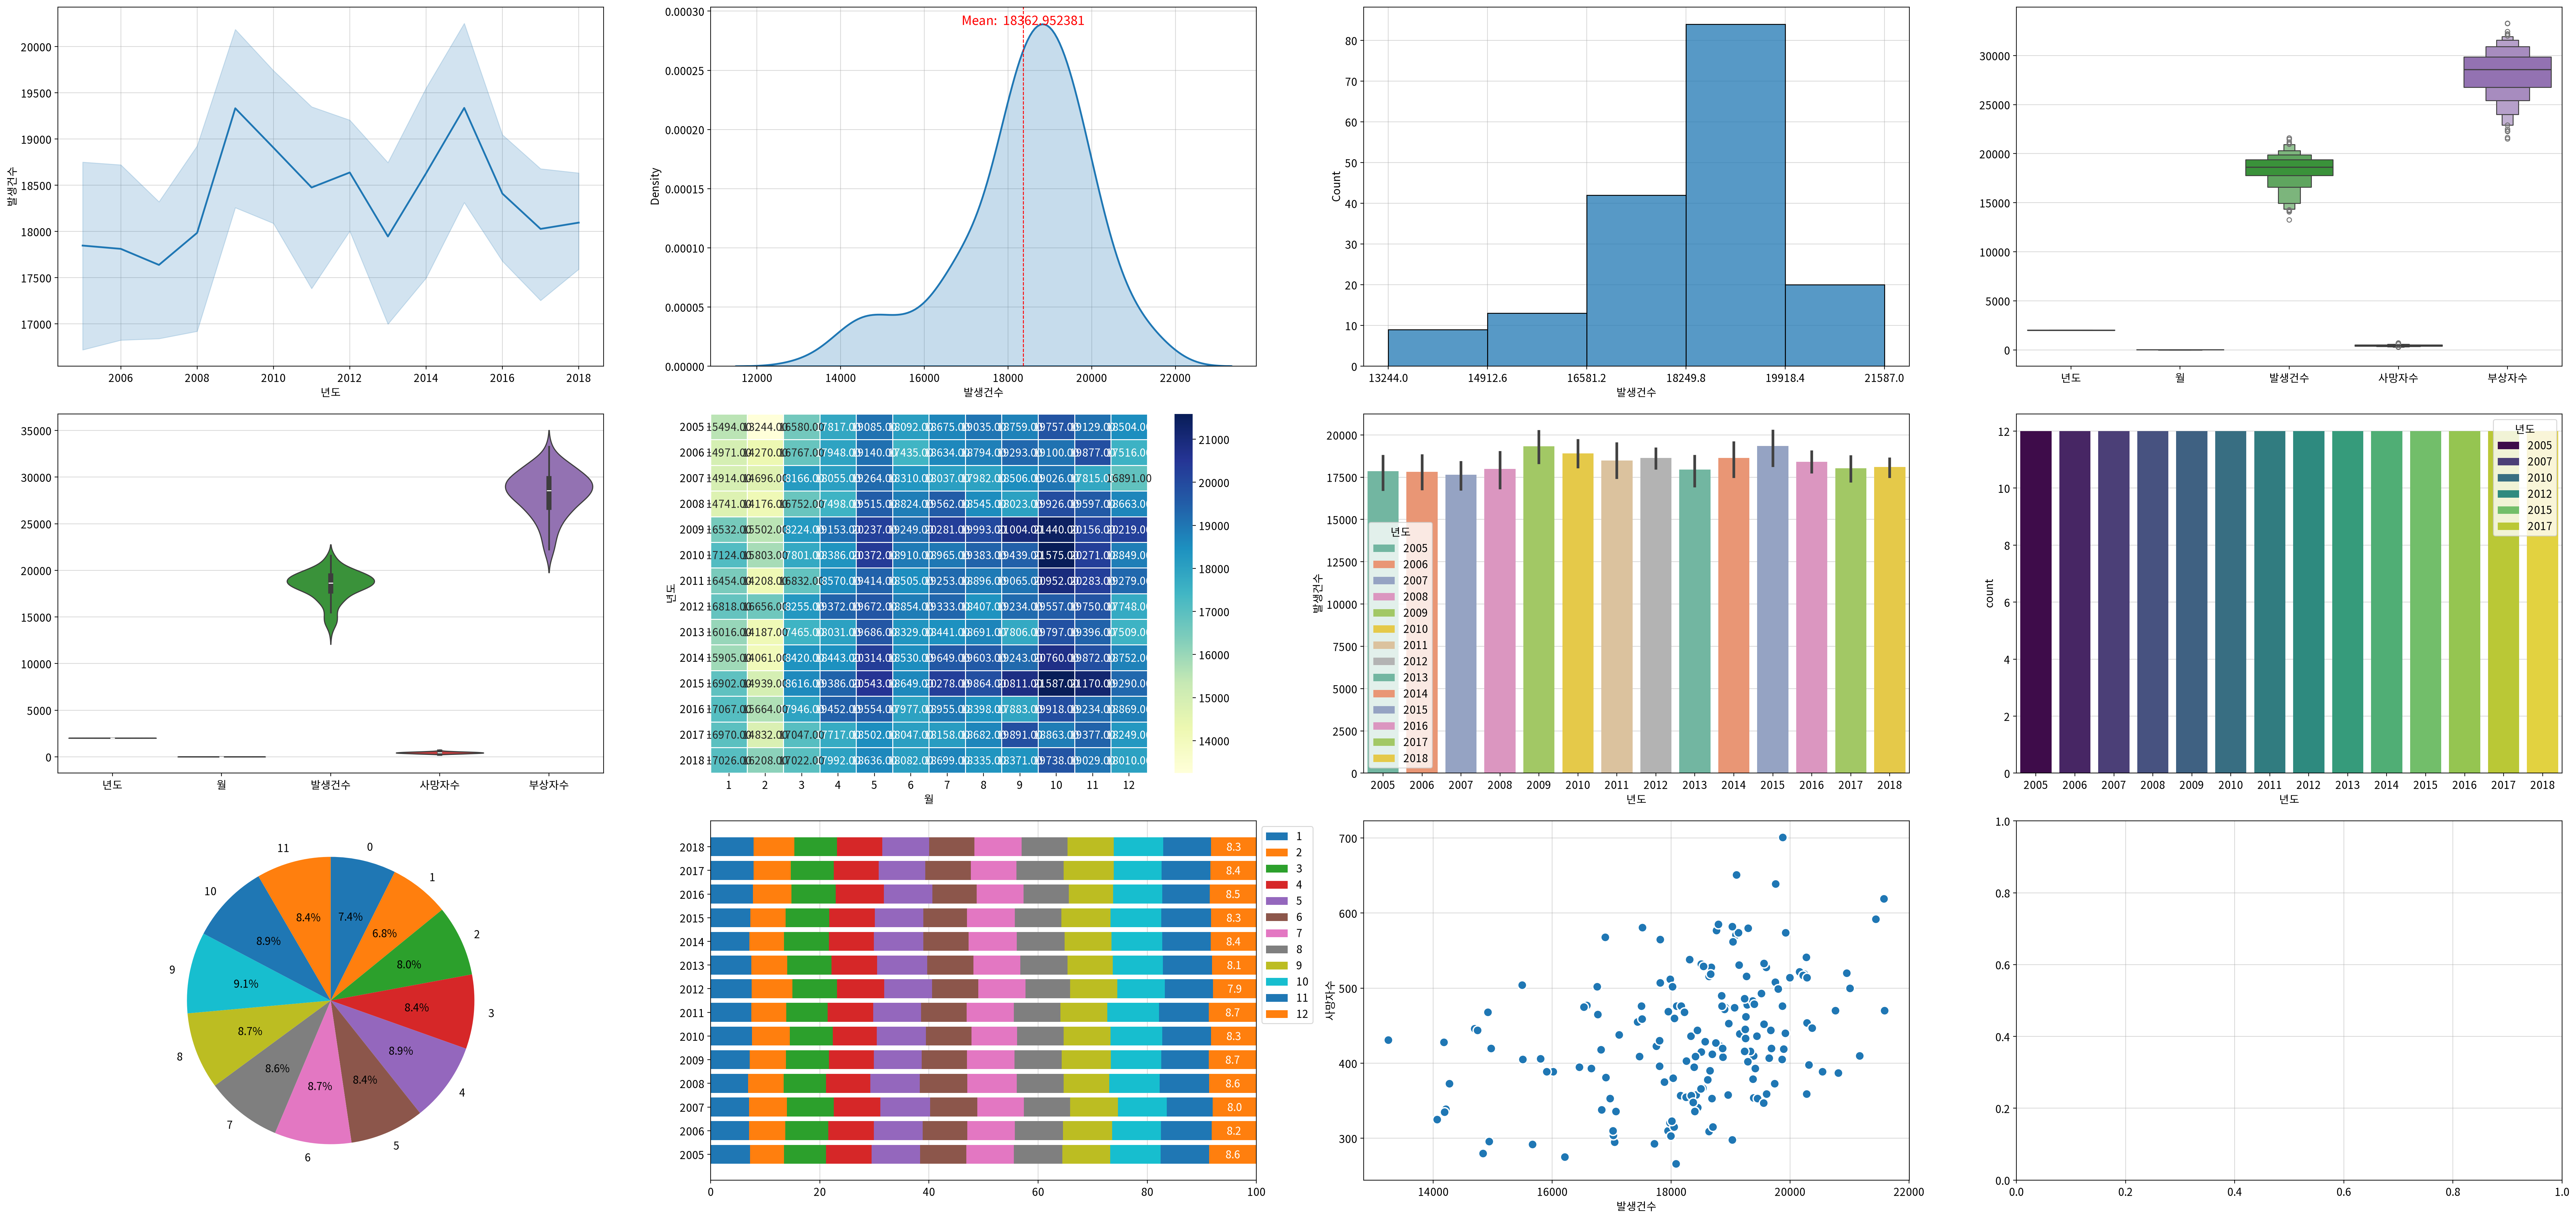

In [10]:
# 그래프 초기화
fig, ax = my_plot.init(rows=3, cols=4, width=1000, height=640)

# 시계열 그래프
my_plot.lineplot(data=origin, x='년도', y='발생건수', ax=ax[0])

# 데이터 분포 시각화
my_plot.kdeplot(data=origin, x='발생건수', fill=True, meanline=True, ax=ax[1])
my_plot.histplot(data=origin, x='발생건수', bins=5, ax=ax[2])
my_plot.boxplot(data=origin, ax=ax[3])
my_plot.violinplot(data=origin, ax=ax[4])
my_plot.heatmap(data=hmdf, palette='YlGnBu', ax=ax[5])

# 집단별 비교 시각화
my_plot.barplot(data=origin, x='년도', y='발생건수', hue='년도', palette='Set2', ax=ax[6])
my_plot.countplot(data=origin, x='년도', hue='년도', palette='viridis', ax=ax[7])
my_plot.pieplot(x=piedf['발생건수'], labels=piedf.index, ax=ax[8])
my_plot.stackplot(data=origin, x='년도', y='발생건수', hue='월', ratio=True, orient='h', ax=ax[9])

# 데이터 관계 시각화
my_plot.scatterplot(data=origin, x='발생건수', y='사망자수', palette='tab10', ax=ax[10])

# 3) 출력
my_plot.show()